In [2]:
import os
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
import operator

load_dotenv()
print("✅ Ready for parallel execution!")

✅ Ready for parallel execution!


### **Parallel Data Processor**

In [3]:
class BatchState(TypedDict):
    items: list  # Items to process
    results: Annotated[list, operator.add] 

class ItemState(TypedDict):
    item: str

def distribute_work(state: BatchState):
    """Distribute items for parallel processing."""
    print(f"📦 Distributing {len(state['items'])} items for processing")
    return [Send("process_item", {"item": item}) for item in state["items"]]

def process_item(state: ItemState) -> dict:
    """Process a single item."""
    item = state["item"]
    print(f"  ⚙️  Processing: {item}")
    result = f"Processed: {item.upper()}"
    return {"results": [result]}


parallel_graph = StateGraph(BatchState)
parallel_graph.add_node("process_item", process_item)

# distribute_work goes here as the conditional edge function, not a node
parallel_graph.add_conditional_edges(START, distribute_work, ["process_item"])
parallel_graph.add_edge("process_item", END)

parallel_app = parallel_graph.compile()

In [4]:
result = parallel_app.invoke({
    "items": ["apple", "banana", "cherry", "date"],
    "results": []
})


📦 Distributing 4 items for processing
  ⚙️  Processing: apple
  ⚙️  Processing: banana
  ⚙️  Processing: cherry
  ⚙️  Processing: date


In [5]:
print("\n📊 Results:")
for r in result["results"]:
    print(f"  • {r}")


📊 Results:
  • Processed: APPLE
  • Processed: BANANA
  • Processed: CHERRY
  • Processed: DATE


In [6]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

class OverallState(TypedDict):
    documents:  list[str]           # input: list of docs to review
    reviews:   Annotated[list[str], operator.add]  # reducer: collects all results
    summary:   str

class WorkerState(TypedDict):
    document:  str   # ← each worker gets ONE document (not the full list)
    doc_index: int   # ← worker also knows which doc it is

def load_documents(state: OverallState):
    """Entry node: loads 4 documents into global state."""
    docs = [
        "Q4 Revenue Report: revenue up 18% YoY",
        "Risk Assessment: supply chain risks identified",
        "Product Roadmap: 3 major features planned for H1",
        "HR Update: headcount grew by 15 in Q4",
    ]
    print(f"📂 Loaded {len(docs)} documents.")
    return {"documents": docs}

def review_document(state: WorkerState):
    """
    Worker node — receives ONE document via Send().
    Note: 'state' here is WorkerState, NOT OverallState.
    Each parallel invocation of this node has a different 'document'.
    """
    doc   = state["document"]
    idx   = state["doc_index"]
    review = f"[Doc {idx+1}] ✅ Reviewed: {doc[:40]}..."
    print(f"  🔎 Worker {idx+1} reviewing doc...")
    return {"reviews": [review]} 

def compile_summary(state: OverallState):
    """Fan-in node: receives all reviews merged by the reducer."""
    print(f"\n📝 All {len(state['reviews'])} reviews collected. Compiling summary...")
    summary = "SUMMARY: " + " | ".join(state["reviews"])
    return {"summary": summary}

def dispatch_reviewers(state: OverallState) -> list[Send]:
    """
    Called as a conditional edge function.
    Returns N Send objects → spawns N parallel review_document workers,
    each with its OWN custom state dict (different document + index).
    """
    return [
        Send("review_document", {"document": doc, "doc_index": i})
        for i, doc in enumerate(state["documents"])
    ]

builder = StateGraph(OverallState)
builder.add_node("load_documents",   load_documents)
builder.add_node("review_document",   review_document)
builder.add_node("compile_summary",   compile_summary)
builder.add_edge(START,               "load_documents")

# ← dispatch_reviewers returns [Send(...), Send(...), ...]
builder.add_conditional_edges("load_documents", dispatch_reviewers, ["review_document"])
builder.add_edge("review_document",   "compile_summary")
builder.add_edge("compile_summary",   END)
graph = builder.compile()

result = graph.invoke({"documents": [], "reviews": [], "summary": ""})
print(f"\n✅ Final summary:\n{result['summary']}")

📂 Loaded 4 documents.
  🔎 Worker 1 reviewing doc...
  🔎 Worker 2 reviewing doc...
  🔎 Worker 3 reviewing doc...
  🔎 Worker 4 reviewing doc...

📝 All 4 reviews collected. Compiling summary...

✅ Final summary:
SUMMARY: [Doc 1] ✅ Reviewed: Q4 Revenue Report: revenue up 18% YoY... | [Doc 2] ✅ Reviewed: Risk Assessment: supply chain risks iden... | [Doc 3] ✅ Reviewed: Product Roadmap: 3 major features planne... | [Doc 4] ✅ Reviewed: HR Update: headcount grew by 15 in Q4...


### **SEND API MORE EXAMPLES**

In [7]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

class OverallState(TypedDict):
    tickets:  list[dict]
    resolved: Annotated[list[str], operator.add]

class TicketState(TypedDict):
    ticket_id: str
    message:  str
    priority: str

def handle_billing(state: TicketState):
    print(f"  💳 BILLING  agent → ticket {state['ticket_id']}: '{state['message'][:30]}'")
    return {"resolved": [f"[BILLING]  {state['ticket_id']} resolved"]}

def handle_tech(state: TicketState):
    print(f"  🔧 TECH     agent → ticket {state['ticket_id']}: '{state['message'][:30]}'")
    return {"resolved": [f"[TECH]     {state['ticket_id']} resolved"]}

def handle_escalation(state: TicketState):
    print(f"  🚨 ESCALATE agent → ticket {state['ticket_id']}: '{state['message'][:30]}' [PRIORITY: {state['priority']}]")
    return {"resolved": [f"[ESCALATE] {state['ticket_id']} escalated to manager"]}

def load_tickets(state: OverallState):
    tickets = [
        {"ticket_id": "T001", "type": "billing",    "priority": "low",      "message": "I was charged twice this month"},
        {"ticket_id": "T002", "type": "tech",       "priority": "medium",   "message": "App crashes on startup"},
        {"ticket_id": "T003", "type": "billing",    "priority": "critical", "message": "Fraudulent charge on account"},
        {"ticket_id": "T004", "type": "tech",       "priority": "low",      "message": "Dark mode not working"},
        {"ticket_id": "T005", "type": "tech",       "priority": "critical", "message": "Data loss after update"},
    ]
    print(f"📥 Loaded {len(tickets)} support tickets.")
    return {"tickets": tickets}

In [8]:
def dispatch_tickets(state: OverallState) -> list[Send]:
    sends = []
    for t in state["tickets"]:
        worker_state = {"ticket_id": t["ticket_id"],
                        "message":   t["message"],
                        "priority":  t["priority"]}
        if t["priority"] == "critical":
            sends.append(Send("handle_escalation", worker_state)) 

        elif t["type"] == "billing":
            sends.append(Send("handle_billing",    worker_state))

        else:
            sends.append(Send("handle_tech",       worker_state))

    print(sends)
    print(f"\n🚦 Dispatching {len(sends)} tickets to different specialist nodes in parallel...")
    return sends

def report(state: OverallState):
    print(f"\n📊 All {len(state['resolved'])} tickets resolved:")
    for r in sorted(state["resolved"]):
        print(f"   {r}")
    return {}

In [9]:
builder = StateGraph(OverallState)
builder.add_node("load_tickets",      load_tickets)
builder.add_node("handle_billing",    handle_billing)
builder.add_node("handle_tech",       handle_tech)
builder.add_node("handle_escalation", handle_escalation)
builder.add_node("report",             report)

builder.add_edge(START,                "load_tickets")
builder.add_conditional_edges(
    "load_tickets", dispatch_tickets,
    ["handle_billing", "handle_tech", "handle_escalation"]  # ← declare all possible targets
)

builder.add_edge("handle_billing",    "report")
builder.add_edge("handle_tech",       "report")
builder.add_edge("handle_escalation", "report")
builder.add_edge("report",             END)

graph = builder.compile()

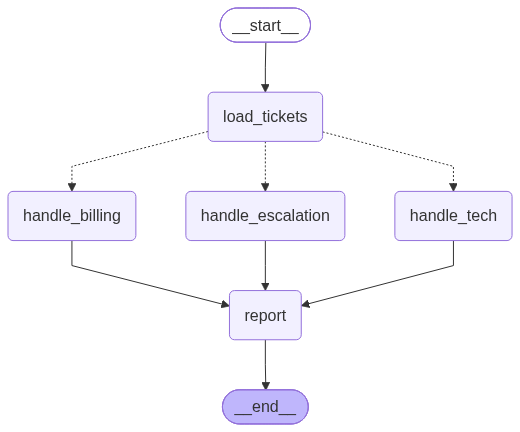

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [11]:
graph.invoke({"tickets": [], "resolved": []})

📥 Loaded 5 support tickets.
[Send(node='handle_billing', arg={'ticket_id': 'T001', 'message': 'I was charged twice this month', 'priority': 'low'}), Send(node='handle_tech', arg={'ticket_id': 'T002', 'message': 'App crashes on startup', 'priority': 'medium'}), Send(node='handle_escalation', arg={'ticket_id': 'T003', 'message': 'Fraudulent charge on account', 'priority': 'critical'}), Send(node='handle_tech', arg={'ticket_id': 'T004', 'message': 'Dark mode not working', 'priority': 'low'}), Send(node='handle_escalation', arg={'ticket_id': 'T005', 'message': 'Data loss after update', 'priority': 'critical'})]

🚦 Dispatching 5 tickets to different specialist nodes in parallel...
  💳 BILLING  agent → ticket T001: 'I was charged twice this month'
  🔧 TECH     agent → ticket T002: 'App crashes on startup'
  🚨 ESCALATE agent → ticket T003: 'Fraudulent charge on account' [PRIORITY: critical]
  🚨 ESCALATE agent → ticket T005: 'Data loss after update' [PRIORITY: critical]
  🔧 TECH     agent → ti

{'tickets': [{'ticket_id': 'T001',
   'type': 'billing',
   'priority': 'low',
   'message': 'I was charged twice this month'},
  {'ticket_id': 'T002',
   'type': 'tech',
   'priority': 'medium',
   'message': 'App crashes on startup'},
  {'ticket_id': 'T003',
   'type': 'billing',
   'priority': 'critical',
   'message': 'Fraudulent charge on account'},
  {'ticket_id': 'T004',
   'type': 'tech',
   'priority': 'low',
   'message': 'Dark mode not working'},
  {'ticket_id': 'T005',
   'type': 'tech',
   'priority': 'critical',
   'message': 'Data loss after update'}],
 'resolved': ['[BILLING]  T001 resolved',
  '[TECH]     T002 resolved',
  '[ESCALATE] T003 escalated to manager',
  '[TECH]     T004 resolved',
  '[ESCALATE] T005 escalated to manager']}

### **VARIABLE FAN-OUT COUNT**

In [12]:
import operator, random
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

class ExamState(TypedDict):
    exam_name:    str
    total_marks:  int
    submissions:  list[dict]
    grades:       Annotated[list[dict], operator.add]

class GraderState(TypedDict):
    student_id:   str
    answers:      list[int]           
    exam_name:    str                
    total_marks:  int  

In [13]:
# ── Phase 1: Simulate collecting submissions ──────────────
def collect_submissions(state: ExamState):
    """
    Simulates receiving N submissions. N is random (3-7).
    The fan-out count will only be known HERE, at runtime.
    """
    random.seed(42)
    n_students   = random.randint(4, 7)
    submissions  = [
        {
            "student_id": f"STU-{i+1:03d}",
            "answers":    [random.randint(0, 10) for _ in range(5)]  # 5 questions
        }
        for i in range(n_students)
    ]
    print(f"📋 Collected {n_students} submissions for '{state['exam_name']}'")
    return {"submissions": submissions}

In [14]:
# ── Dispatch: VARIABLE number of graders ──────────────────
def dispatch_graders(state: ExamState) -> list[Send]:
    """
    Returns len(submissions) Send objects — one per student.
    Each worker also receives exam_name and total_marks as context.
    The exact number is ONLY known here at runtime!
    """
    n = len(state["submissions"])
    print(f"⚡ Spawning {n} grader workers dynamically...")
    return [
        Send("grade_submission", {
            "student_id":  sub["student_id"],
            "answers":     sub["answers"],
            # ↓ EXTRA METADATA passed alongside the item
            "exam_name":   state["exam_name"],
            "total_marks": state["total_marks"],
        })
        for sub in state["submissions"]
    ]


In [15]:
# ── Worker: grades one student's answers ─────────────────
def grade_submission(state: GraderState):
    raw       = sum(state["answers"])
    pct       = round(raw / state["total_marks"] * 100, 1)
    grade     = "A" if pct>=80 else "B" if pct>=65 else "C" if pct>=50 else "F"
    result    = {"student":state["student_id"], "score":raw, "pct":pct, "grade":grade}
    print(f"  📝 {state['student_id']}: {raw}/{state['total_marks']} = {pct}% → Grade {grade}")
    return {"grades": [result]}

In [16]:
# ── Reduce: compute class statistics ──────────────────────
def compute_stats(state: ExamState):
    grades  = state["grades"]
    avg     = round(sum(g["pct"] for g in grades) / len(grades), 1)
    top     = max(grades, key=lambda x: x["pct"])
    dist    = {}
    for g in grades:
        dist[g["grade"]] = dist.get(g["grade"], 0) + 1
    print(f"\n📊 {state['exam_name']} Results ({len(grades)} students):")
    print(f"   Class average : {avg}%")
    print(f"   Top student   : {top['student']} ({top['pct']}%)")
    print(f"   Grade dist    : {dist}")
    return {}


In [17]:
builder = StateGraph(ExamState)
builder.add_node("collect_submissions", collect_submissions)
builder.add_node("grade_submission",    grade_submission)
builder.add_node("compute_stats",       compute_stats)
builder.add_edge(START,                  "collect_submissions")
builder.add_conditional_edges("collect_submissions", dispatch_graders, ["grade_submission"])
builder.add_edge("grade_submission", "compute_stats")
builder.add_edge("compute_stats",    END)
graph = builder.compile()

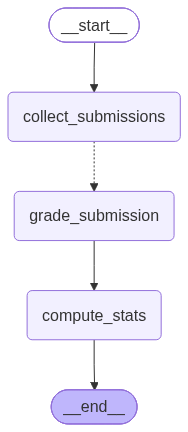

In [18]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [19]:
graph.invoke({
    "exam_name":   "Advanced LLMs & RAG Midterm",
    "total_marks": 50,
    "submissions": [],
    "grades":      [],
})

📋 Collected 4 submissions for 'Advanced LLMs & RAG Midterm'
⚡ Spawning 4 grader workers dynamically...
  📝 STU-001: 12/50 = 24.0% → Grade F
  📝 STU-002: 29/50 = 58.0% → Grade C
  📝 STU-003: 10/50 = 20.0% → Grade F
  📝 STU-004: 28/50 = 56.0% → Grade C

📊 Advanced LLMs & RAG Midterm Results (4 students):
   Class average : 39.5%
   Top student   : STU-002 (58.0%)
   Grade dist    : {'F': 2, 'C': 2}


{'exam_name': 'Advanced LLMs & RAG Midterm',
 'total_marks': 50,
 'submissions': [{'student_id': 'STU-001', 'answers': [0, 4, 3, 3, 2]},
  {'student_id': 'STU-002', 'answers': [1, 10, 8, 1, 9]},
  {'student_id': 'STU-003', 'answers': [6, 0, 0, 1, 3]},
  {'student_id': 'STU-004', 'answers': [3, 8, 9, 0, 8]}],
 'grades': [{'student': 'STU-001', 'score': 12, 'pct': 24.0, 'grade': 'F'},
  {'student': 'STU-002', 'score': 29, 'pct': 58.0, 'grade': 'C'},
  {'student': 'STU-003', 'score': 10, 'pct': 20.0, 'grade': 'F'},
  {'student': 'STU-004', 'score': 28, 'pct': 56.0, 'grade': 'C'}]}

### **FIXED: CHAINED SEND**

In [20]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# ── States ────────────────────────────────────────────────
class AuditState(TypedDict):
    company:   str
    dept_data: Annotated[list[dict], operator.add]  # level 1 workers write here
    audit_log: Annotated[list[str],  operator.add]  # all workers append here

class DeptState(TypedDict):  # private state for level 1 workers
    company:   str
    dept:      str
    employees: list[str]

class EmpState(TypedDict):   # private state for level 2 workers
    company:   str
    dept:      str
    employee:  str

In [21]:
# ── Level 0: Entry node ───────────────────────────────────
def start_audit(state: AuditState):
    print(f"🏢 Starting HR audit for: {state['company']}")
    return {"audit_log": [f"Audit started for {state['company']}"]}

# ── Level 0 → Level 1 dispatch ────────────────────────────
def dispatch_departments(state: AuditState) -> list[Send]:
    """FIRST fan-out: one Send per department."""
    departments = {
        "Engineering": ["Alice", "Bob", "Charlie"],
        "Marketing":   ["Diana", "Eve"],
        "Finance":     ["Frank", "Grace", "Henry", "Ivy"],
    }
    print(f"\n  📂 Fan-out LEVEL 1: dispatching {len(departments)} dept auditors in parallel...")
    return [
        Send("audit_department", {
            "company":   state["company"],
            "dept":      dept,
            "employees": emps,
        })
        for dept, emps in departments.items()
    ]

In [23]:
# ── Level 1 worker: RETURNS A DICT (not Send objects!) ────
def audit_department(state: DeptState):
    """
    FIX: This node now correctly returns a dict.
    It stores employee data into 'dept_data' via the reducer
    so the level 2 dispatcher can read them later.
    """
    print(f"  🗂  [{state['dept']}] auditing dept — {len(state['employees'])} employees found")
    return {
        "dept_data": [{            # ← written to global AuditState via operator.add
            "company":   state["company"],
            "dept":      state["dept"],
            "employees": state["employees"],
        }],
        "audit_log": [f"Dept audited: {state['dept']} ({len(state['employees'])} employees)"],
    }

In [24]:
# ── Intermediate fan-in: waits for ALL level 1 workers ────
def collect_depts(state: AuditState):
    """
    FIX: This new intermediate node runs AFTER all audit_department
    workers complete and their results are merged into AuditState.
    It's a passthrough — just confirms collection before level 2 dispatch.
    """
    total = sum(len(d["employees"]) for d in state["dept_data"])
    print(f"\n  ✅ All {len(state['dept_data'])} depts collected. Total employees: {total}")
    return {}

In [25]:
# ── Level 1 → Level 2 dispatch ────────────────────────────
def dispatch_employees(state: AuditState) -> list[Send]:
    """
    SECOND fan-out: reads dept_data that was collected from all
    level 1 workers and spawns one Send per employee.
    """
    sends = [
        Send("audit_employee", {
            "company":  d["company"],
            "dept":     d["dept"],
            "employee": emp,
        })
        for d in state["dept_data"]
        for emp in d["employees"]
    ]
    print(f"  📂 Fan-out LEVEL 2: dispatching {len(sends)} employee auditors in parallel...")
    return sends

In [26]:
# ── Level 2 worker: leaf node, returns dict ───────────────
def audit_employee(state: EmpState):
    entry = f"✓ {state['company']} | {state['dept']:12s} | {state['employee']}"
    print(f"    👤 {entry}")
    return {"audit_log": [entry]}

# ── Final fan-in: compile report ──────────────────────────
def compile_report(state: AuditState):
    emp_logs = [l for l in state["audit_log"] if l.startswith("✓")]
    print(f"\n📋 AUDIT COMPLETE — {len(emp_logs)} employees audited:")
    for log in sorted(emp_logs):
        print(f"   {log}")
    return {}

In [27]:
# ── Build Graph ───────────────────────────────────────────
builder = StateGraph(AuditState)
builder.add_node("start_audit",       start_audit)
builder.add_node("audit_department",  audit_department)   # level 1: returns dict ✅
builder.add_node("collect_depts",     collect_depts)      # intermediate fan-in node ✅
builder.add_node("audit_employee",    audit_employee)     # level 2: returns dict ✅
builder.add_node("compile_report",    compile_report)

builder.add_edge(START,                "start_audit")
# Level 1 fan-out
builder.add_conditional_edges("start_audit",   dispatch_departments, ["audit_department"])
# Fan-in: all level 1 workers → collect_depts
builder.add_edge("audit_department",           "collect_depts")
# Level 2 fan-out
builder.add_conditional_edges("collect_depts", dispatch_employees,   ["audit_employee"])
# Fan-in: all level 2 workers → compile_report
builder.add_edge("audit_employee",             "compile_report")
builder.add_edge("compile_report",             END)

graph = builder.compile()
graph.invoke({"company": "KrishAI Technologies", "dept_data": [], "audit_log": []})

🏢 Starting HR audit for: KrishAI Technologies

  📂 Fan-out LEVEL 1: dispatching 3 dept auditors in parallel...
  🗂  [Engineering] auditing dept — 3 employees found
  🗂  [Marketing] auditing dept — 2 employees found
  🗂  [Finance] auditing dept — 4 employees found

  ✅ All 3 depts collected. Total employees: 9
  📂 Fan-out LEVEL 2: dispatching 9 employee auditors in parallel...
    👤 ✓ KrishAI Technologies | Engineering  | Alice
    👤 ✓ KrishAI Technologies | Engineering  | Charlie
    👤 ✓ KrishAI Technologies | Engineering  | Bob
    👤 ✓ KrishAI Technologies | Marketing    | Eve
    👤 ✓ KrishAI Technologies | Finance      | Grace
    👤 ✓ KrishAI Technologies | Finance      | Frank
    👤 ✓ KrishAI Technologies | Marketing    | Diana
    👤 ✓ KrishAI Technologies | Finance      | Henry
    👤 ✓ KrishAI Technologies | Finance      | Ivy

📋 AUDIT COMPLETE — 9 employees audited:
   ✓ KrishAI Technologies | Engineering  | Alice
   ✓ KrishAI Technologies | Engineering  | Bob
   ✓ KrishAI Technol

{'company': 'KrishAI Technologies',
 'dept_data': [{'company': 'KrishAI Technologies',
   'dept': 'Engineering',
   'employees': ['Alice', 'Bob', 'Charlie']},
  {'company': 'KrishAI Technologies',
   'dept': 'Marketing',
   'employees': ['Diana', 'Eve']},
  {'company': 'KrishAI Technologies',
   'dept': 'Finance',
   'employees': ['Frank', 'Grace', 'Henry', 'Ivy']}],
 'audit_log': ['Audit started for KrishAI Technologies',
  'Dept audited: Engineering (3 employees)',
  'Dept audited: Marketing (2 employees)',
  'Dept audited: Finance (4 employees)',
  '✓ KrishAI Technologies | Engineering  | Alice',
  '✓ KrishAI Technologies | Engineering  | Bob',
  '✓ KrishAI Technologies | Engineering  | Charlie',
  '✓ KrishAI Technologies | Marketing    | Diana',
  '✓ KrishAI Technologies | Marketing    | Eve',
  '✓ KrishAI Technologies | Finance      | Frank',
  '✓ KrishAI Technologies | Finance      | Grace',
  '✓ KrishAI Technologies | Finance      | Henry',
  '✓ KrishAI Technologies | Finance   

### **WORKERS ROUTE TO DIFFERENT DOWNSTREAM NODES**

In [28]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command

class RAGState(TypedDict):
    query:    str
    chunks:   list[dict]
    used:     Annotated[list[str], operator.add]   # kept chunks
    discarded:Annotated[list[str], operator.add]   # dropped chunks
    answer:   str

class ChunkState(TypedDict):
    query:    str
    chunk_id: str
    text:     str
    score:    float   # relevance score pre-computed

# ── Entry: simulate retrieval ─────────────────────────────
def retrieve_chunks(state: RAGState):
    chunks = [
        {"chunk_id":"C1","text":"LangGraph supports stateful multi-agent workflows","score":0.91},
        {"chunk_id":"C2","text":"The weather in Paris is 22 degrees today",       "score":0.12},
        {"chunk_id":"C3","text":"Send API enables dynamic parallel node dispatch",   "score":0.88},
        {"chunk_id":"C4","text":"Recipe for pasta carbonara requires eggs and cheese","score":0.08},
        {"chunk_id":"C5","text":"Checkpointers enable persistence across graph runs", "score":0.76},
        {"chunk_id":"C6","text":"Stock price of AAPL closed at $189 yesterday",      "score":0.31},
    ]
    print(f"📥 Retrieved {len(chunks)} chunks for query: '{state['query']}'")
    return {"chunks": chunks}

In [29]:
# ── Dispatch: one worker per chunk ────────────────────────
def dispatch_scorers(state: RAGState) -> list[Send]:
    print(f"\n⚡ Dispatching {len(state['chunks'])} chunk scorers in parallel...")
    return [
        Send("score_chunk", {
            "query":    state["query"],
            "chunk_id": c["chunk_id"],
            "text":     c["text"],
            "score":    c["score"],
        })
        for c in state["chunks"]
    ]

In [30]:
# ── Worker: scores chunk AND routes to different next nodes ─
def score_chunk(state: ChunkState) -> Command[Literal["use_chunk", "discard_chunk"]]:
    """
    Worker receives one chunk via Send().
    Based on score, routes to a DIFFERENT downstream node via Command.
    → score >= 0.6  : use_chunk   (high quality)
    → score <  0.6  : discard_chunk (low quality)
    This is the KEY insight: Send + Command together = dynamic fan-out
    with per-item routing to different nodes.
    """
    threshold = 0.6
    if state["score"] >= threshold:
        print(f"  ✅ {state['chunk_id']} score={state['score']:.2f} → use_chunk")
        return Command(
            update={"used": [f"{state['chunk_id']}: {state['text'][:45]}..."]},
            goto="use_chunk",
        )
    else:
        print(f"  ❌ {state['chunk_id']} score={state['score']:.2f} → discard_chunk")
        return Command(
            update={"discarded": [f"{state['chunk_id']}: score too low ({state['score']:.2f})"]},
            goto="discard_chunk",
        )

In [33]:
def use_chunk(state: RAGState):
    print(f"  📎 use_chunk: adding to context window")
    return {}

def discard_chunk(state: RAGState):
    print(f"  🗑  discard_chunk: dropping from context")
    return {}

def generate_answer(state: RAGState):
    print(f"\n🤖 Generating answer from {len(state['used'])} high-quality chunks")
    print(f"   Used    : {[c.split(':')[0] for c in state['used']]}")
    print(f"   Discarded: {[c.split(':')[0] for c in state['discarded']]}")
    answer = f"Answer using {len(state['used'])} relevant chunks: [LLM response here]"
    return {"answer": answer}

builder = StateGraph(RAGState)
builder.add_node("retrieve_chunks", retrieve_chunks)
builder.add_node("score_chunk",     score_chunk)
builder.add_node("use_chunk",       use_chunk)
builder.add_node("discard_chunk",   discard_chunk)
builder.add_node("generate_answer", generate_answer)
builder.add_edge(START,              "retrieve_chunks")
builder.add_conditional_edges("retrieve_chunks", dispatch_scorers, ["score_chunk"])
# score_chunk uses Command(goto=...) internally, so no edge needed from it
builder.add_edge("use_chunk",       "generate_answer")
builder.add_edge("discard_chunk",   "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

graph.invoke({
    "query":     "How does LangGraph handle state persistence?",
    "chunks":    [],
    "used":      [],
    "discarded": [],
    "answer":    "",
})

📥 Retrieved 6 chunks for query: 'How does LangGraph handle state persistence?'

⚡ Dispatching 6 chunk scorers in parallel...
  ✅ C1 score=0.91 → use_chunk
  ❌ C2 score=0.12 → discard_chunk
  ✅ C3 score=0.88 → use_chunk
  ❌ C4 score=0.08 → discard_chunk
  ❌ C6 score=0.31 → discard_chunk
  ✅ C5 score=0.76 → use_chunk
  🗑  discard_chunk: dropping from context
  📎 use_chunk: adding to context window

🤖 Generating answer from 3 high-quality chunks
   Used    : ['C1', 'C3', 'C5']
   Discarded: ['C2', 'C4', 'C6']


{'query': 'How does LangGraph handle state persistence?',
 'chunks': [{'chunk_id': 'C1',
   'text': 'LangGraph supports stateful multi-agent workflows',
   'score': 0.91},
  {'chunk_id': 'C2',
   'text': 'The weather in Paris is 22 degrees today',
   'score': 0.12},
  {'chunk_id': 'C3',
   'text': 'Send API enables dynamic parallel node dispatch',
   'score': 0.88},
  {'chunk_id': 'C4',
   'text': 'Recipe for pasta carbonara requires eggs and cheese',
   'score': 0.08},
  {'chunk_id': 'C5',
   'text': 'Checkpointers enable persistence across graph runs',
   'score': 0.76},
  {'chunk_id': 'C6',
   'text': 'Stock price of AAPL closed at $189 yesterday',
   'score': 0.31}],
 'used': ['C1: LangGraph supports stateful multi-agent workf...',
  'C3: Send API enables dynamic parallel node dispat...',
  'C5: Checkpointers enable persistence across graph...'],
 'discarded': ['C2: score too low (0.12)',
  'C4: score too low (0.08)',
  'C6: score too low (0.31)'],
 'answer': 'Answer using 3 releva

### **Subgraphs for Multi-Agent Systems**

In [34]:
# Define a reusable subgraph for an agent
class AgentState(TypedDict):
    task: str
    result: str

def researcher_node(state: AgentState) -> dict:
    """Research agent subgraph."""
    task = state["task"]
    print(f"🔍 Researcher working on: {task}")
    return {"result": f"Research findings for: {task}"}

def analyzer_node(state: AgentState) -> dict:
    """Analyzer agent subgraph."""
    task = state["task"]
    print(f"📊 Analyzer working on: {task}")
    return {"result": f"Analysis of: {task}"}

# Build subgraphs
researcher_graph = StateGraph(AgentState)
researcher_graph.add_node("research", researcher_node)
researcher_graph.add_edge(START, "research")
researcher_graph.add_edge("research", END)
researcher_subgraph = researcher_graph.compile()

analyzer_graph = StateGraph(AgentState)
analyzer_graph.add_node("analyze", analyzer_node)
analyzer_graph.add_edge(START, "analyze")
analyzer_graph.add_edge("analyze", END)
analyzer_subgraph = analyzer_graph.compile()

print("✅ Subgraphs created!")

✅ Subgraphs created!


In [35]:
class PreprocState(TypedDict):
    text:      str   # shared with parent
    char_count:int   # private — only inside subgraph A

def clean_text(state: PreprocState):
    cleaned = state["text"].strip().lower()
    print(f"  [SubA] clean_text: '{cleaned[:30]}...'")
    return {"text": cleaned}

def count_chars(state: PreprocState):
    n = len(state["text"])
    print(f"  [SubA] count_chars: {n} chars")
    return {"char_count": n}

preproc_builder = StateGraph(PreprocState)
preproc_builder.add_node("clean_text",  clean_text)
preproc_builder.add_node("count_chars", count_chars)
preproc_builder.add_edge(START,          "clean_text")
preproc_builder.add_edge("clean_text",  "count_chars")
preproc_builder.add_edge("count_chars", END)
preproc_subgraph = preproc_builder.compile()  

In [36]:
class AnalysisState(TypedDict):
    text:      str    # shared with parent
    keywords: list[str]  # private — only inside subgraph B

def extract_keywords(state: AnalysisState):
    words    = [w for w in state["text"].split() if len(w) > 5]
    print(f"  [SubB] extract_keywords: {words[:4]}")
    return {"keywords": words}

def score_sentiment(state: AnalysisState):
    pos_words = ["great", "good", "excellent", "amazing", "fantastic"]
    score     = sum(1 for w in state["keywords"] if w in pos_words)
    label     = "positive" if score > 0 else "neutral"
    # Only 'text' is shared back to parent — 'keywords' stays private
    print(f"  [SubB] score_sentiment: {label}")
    return {"text": f"[{label.upper()}] {state['text']}"}

analysis_builder = StateGraph(AnalysisState)
analysis_builder.add_node("extract_keywords", extract_keywords)
analysis_builder.add_node("score_sentiment",  score_sentiment)
analysis_builder.add_edge(START,               "extract_keywords")
analysis_builder.add_edge("extract_keywords", "score_sentiment")
analysis_builder.add_edge("score_sentiment",  END)
analysis_subgraph = analysis_builder.compile()

In [37]:
# ── Parent Graph ───────────────────────────────────────────
# Uses both subgraphs as plain nodes via add_node()
class ParentState(TypedDict):
    text:   str   # shared key — subgraphs read & write this
    result: str

def format_result(state: ParentState):
    print(f"  [Parent] Formatting result.")
    return {"result": f"DONE: {state['text']}"}

parent = StateGraph(ParentState)
parent.add_node("preprocess", preproc_subgraph)    # ← subgraph as node!
parent.add_node("analyse",     analysis_subgraph)   # ← subgraph as node!
parent.add_node("format",      format_result)
parent.add_edge(START,         "preprocess")
parent.add_edge("preprocess",  "analyse")
parent.add_edge("analyse",     "format")
parent.add_edge("format",      END)
graph = parent.compile()

print("🚀 Running parent graph with 2 subgraphs...\n")
out = graph.invoke({"text": "  LangGraph is Great for building Agentic AI systems!  ", "result": ""})
print(f"\n✅ {out['result']}")

🚀 Running parent graph with 2 subgraphs...

  [SubA] clean_text: 'langgraph is great for buildin...'
  [SubA] count_chars: 51 chars
  [SubB] extract_keywords: ['langgraph', 'building', 'agentic', 'systems!']
  [SubB] score_sentiment: neutral
  [Parent] Formatting result.

✅ DONE: [NEUTRAL] langgraph is great for building agentic ai systems!


## **Advanced Project: Multi-Agent Research System**

In [38]:
from langgraph.graph.message import add_messages

class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    research_results: list
    analysis_results: list
    final_report: str

researcher_llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    temperature=0.7,
)
analyzer_llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    temperature=0.7,
)

synthesizer_llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    temperature=0.7,
)
def coordinator(state: MultiAgentState):
    query = state["messages"][-1].content
    print(f"🎯 Coordinator: Distributing task: {query}")
    return [
        Send("researcher", state),
        Send("analyzer", state)
    ]

def researcher(state: MultiAgentState) -> dict:
    query = state["messages"][-1].content
    print("🔬 Researcher: Gathering information...")
    response = researcher_llm.invoke([
        HumanMessage(content=f"Research this topic and provide key facts: {query}")
    ])
    return {"research_results": [response.content]}

def analyzer(state: MultiAgentState) -> dict:
    query = state["messages"][-1].content
    print("📊 Analyzer: Evaluating sources...")
    response = analyzer_llm.invoke([
        HumanMessage(content=f"Analyze the credibility and relevance of information about: {query}")
    ])
    return {"analysis_results": [response.content]}

def synthesizer(state: MultiAgentState) -> dict:
    """Synthesize all findings into a coherent report."""
    print("✍️  Synthesizer: Creating final report...")
    
    research = "\n".join(state.get("research_results", []))
    analysis = "\n".join(state.get("analysis_results", []))
    
    response = synthesizer_llm.invoke([
        HumanMessage(content=f"Synthesize these findings into a coherent report:\n\nResearch:\n{research}\n\nAnalysis:\n{analysis}")
    ])
    
    return {"final_report": response.content}

multi_agent_builder = StateGraph(MultiAgentState)
# Remove: multi_agent_builder.add_node("coordinator", coordinator)
multi_agent_builder.add_node("researcher", researcher)
multi_agent_builder.add_node("analyzer", analyzer)
multi_agent_builder.add_node("synthesizer", synthesizer)

# coordinator goes here as the edge function from START
multi_agent_builder.add_conditional_edges(START, coordinator, ["researcher", "analyzer"])
multi_agent_builder.add_edge("researcher", "synthesizer")
multi_agent_builder.add_edge("analyzer", "synthesizer")
multi_agent_builder.add_edge("synthesizer", END)

multi_agent_system = multi_agent_builder.compile()

print("✅ Multi-agent research system ready!")

✅ Multi-agent research system ready!


In [39]:
result = multi_agent_system.invoke({
    "messages": [HumanMessage(content="Explain the impact of quantum computing on cryptography")],
    "research_results": [],
    "analysis_results": [],
    "final_report": ""
})

print("\n" + "=" * 70)
print("📄 Final Research Report")
print("=" * 70)
print(result["final_report"])
print("=" * 70)

🎯 Coordinator: Distributing task: Explain the impact of quantum computing on cryptography
🔬 Researcher: Gathering information...
📊 Analyzer: Evaluating sources...
✍️  Synthesizer: Creating final report...

📄 Final Research Report
### **Impact of Quantum Computing on Cryptography: A Comprehensive Report**

---

#### **1. Introduction**
Quantum computing is a rapidly evolving technology that leverages principles of quantum mechanics, such as superposition, entanglement, and quantum interference, to perform computations at speeds far exceeding those of classical computers for certain tasks. While this innovation holds immense promise for various industries, it also poses a significant threat to the cryptographic systems that underpin global cybersecurity. This report explores the disruptive nature of quantum computing, its implications for cryptography, and the ongoing efforts to mitigate associated risks.

---

#### **2. The Disruptive Nature of Quantum Computing**
Quantum computers are 

In [40]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

In [41]:
# ── Shared state across all agents ────────────────────────
class AgentState(TypedDict):
    task:     str
    log:      Annotated[list[str], operator.add]
    result:   str

# ── Specialist Sub-Agents (each is a subgraph) ────────────

# Sub-Agent 1: Web Research Agent
class WebState(TypedDict):
    task:   str
    log:    Annotated[list[str], operator.add]
    result: str

In [42]:
def web_search(state: WebState):
    print("  🌐 WebAgent: searching the web...")
    return {"log": ["web_search completed"]}

def web_summarize(state: WebState):
    print("  🌐 WebAgent: summarizing results...")
    summary = f"[WEB RESULT] Found 5 sources about: {state['task']}"
    return {"result": summary, "log": ["web_summarize completed"]}

In [43]:
web_builder = StateGraph(WebState)
web_builder.add_node("web_search",    web_search)
web_builder.add_node("web_summarize", web_summarize)
web_builder.add_edge(START,            "web_search")
web_builder.add_edge("web_search",    "web_summarize")
web_builder.add_edge("web_summarize", END)
web_agent = web_builder.compile()

In [ ]:
# Sub-Agent 2: Code Agent
class CodeState(TypedDict):
    task:   str
    log:    Annotated[list[str], operator.add]
    result: str

def write_code(state: CodeState):
    print("  💻 CodeAgent: writing code...")
    return {"log": ["write_code completed"]}

def test_code(state: CodeState):
    print("  💻 CodeAgent: running tests...")
    code_out = f"[CODE RESULT] Python solution for: {state['task']}"
    return {"result": code_out, "log": ["test_code completed"]}

code_builder = StateGraph(CodeState)
code_builder.add_node("write_code", write_code)
code_builder.add_node("test_code",  test_code)
code_builder.add_edge(START,        "write_code")
code_builder.add_edge("write_code", "test_code")
code_builder.add_edge("test_code",  END)
code_agent = code_builder.compile()



In [45]:
# ── Orchestrator Node ─────────────────────────────────────
# Reads the task, decides which specialist to route to
def orchestrator(state: AgentState) -> Command[Literal["web_agent", "code_agent"]]:
    task = state["task"].lower()
    print(f"🎯 Orchestrator received: '{state['task']}'")

    # Simple rule-based routing (would be an LLM in production)
    if "code" in task or "python" in task or "function" in task:
        print("  → Routing to CODE AGENT")
        return Command(update={"log": ["orchestrator: delegated to code_agent"]},
                       goto="code_agent")
    else:
        print("  → Routing to WEB AGENT")
        return Command(update={"log": ["orchestrator: delegated to web_agent"]},
                       goto="web_agent")

def synthesizer(state: AgentState):
    print(f"\n📋 Synthesizer received result: {state['result'][:50]}...")
    print(f"   Full log: {state['log']}")
    return {}

# ── Parent / Orchestrator Graph ────────────────────────────
builder = StateGraph(AgentState)
builder.add_node("orchestrator", orchestrator)
builder.add_node("web_agent",     web_agent)   # ← subgraph!
builder.add_node("code_agent",    code_agent)  # ← subgraph!
builder.add_node("synthesizer",   synthesizer)
builder.add_edge(START,           "orchestrator")
builder.add_edge("web_agent",     "synthesizer")
builder.add_edge("code_agent",    "synthesizer")
builder.add_edge("synthesizer",   END)
graph = builder.compile()

# ── Test both routing paths ───────────────────────────────
for task in ["Research latest AI trends in 2025",
              "Write a Python function to sort a list"]:
    print(f"\n{'='*55}\n📥 Task: {task}")
    graph.invoke({"task": task, "log": [], "result": ""})


📥 Task: Research latest AI trends in 2025
🎯 Orchestrator received: 'Research latest AI trends in 2025'
  → Routing to WEB AGENT
  🌐 WebAgent: searching the web...
  🌐 WebAgent: summarizing results...

📋 Synthesizer received result: [WEB RESULT] Found 5 sources about: Research lates...
   Full log: ['orchestrator: delegated to web_agent', 'orchestrator: delegated to web_agent', 'web_search completed', 'web_summarize completed']

📥 Task: Write a Python function to sort a list
🎯 Orchestrator received: 'Write a Python function to sort a list'
  → Routing to CODE AGENT
  💻 CodeAgent: writing code...
  💻 CodeAgent: running tests...

📋 Synthesizer received result: [CODE RESULT] Python solution for: Write a Python ...
   Full log: ['orchestrator: delegated to code_agent', 'orchestrator: delegated to code_agent', 'write_code completed', 'test_code completed']
